## Introduction to the automatic differentiation framework (reverse accumulation mode)

### Basic elements (cost function, manual gradient descent)

We import the libraries

In [1]:
import gpt as g
import numpy as np
import matplotlib.pyplot as plt

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x300000000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

and setup a basic RNG, grid, and module shortcut

In [2]:
rng = g.random("test3")
grid = g.grid([4, 4, 4, 4], g.double)
rad = g.ad.reverse

GPT :       0.329592 s : Initializing gpt.random(test3,vectorized_ranlux24_389_64) took 0.000178099 s


With this, we can now define a minimal model and training target

In [3]:
V_in = rad.node(g.complex(grid))
V_out = rad.node(g.complex(grid))

rng.cnormal(V_in.value)
rng.cnormal(V_out.value)

c = g.norm2(V_in - V_out)

print(c)

(inner_product):
 (-):
  leaf(lattice;ot_complex_additive_group;4356379440)
  leaf(lattice;ot_complex_additive_group;4356379440)
 (-):
  leaf(lattice;ot_complex_additive_group;4356379440)
  leaf(lattice;ot_complex_additive_group;4356379440)


we first verify that both fields are different

In [4]:
print(g.norm2(V_in.value - V_out.value))

1004.2630610592337


and now perform a simple gradient descent to learn V_out to minimize the cost c

In [5]:
for i in range(100):
    cv = c()
    if i % 10 == 0:
        print(i, cv)
    V_out.value -= 0.1 * V_out.gradient

0 (1004.2630610592337+9.577911277530653e-16j)
10 (11.578364793774895-2.4362666752926576e-17j)
20 (0.13348945758925906-2.316043041397405e-19j)
30 (0.0015390286629296075-1.823603900471013e-21j)
40 (1.7743792416978686e-05-4.403674402676033e-23j)
50 (2.045719985081435e-07-2.593803886085082e-25j)
60 (2.358554563192993e-09-9.751689944166233e-28j)
70 (2.7192282754885348e-11+4.762246973486318e-29j)
80 (3.1350567544807327e-13+9.079255055016765e-31j)
90 (3.614474349683836e-15-5.89816045468591e-34j)


we now verify that the fields are identical

In [6]:
print(g.norm2(V_out.value - V_in.value))

4.167205396494112e-17


## Restricting the optimization manifold

Next, we repeat the above process, however, we reduce the optimization manifold from $\mathbb{C}$ to U(1)

In [7]:
V_in = rad.node(g.complex(grid))
V_out = rad.node(g.u1(grid))

rng.cnormal(V_in.value)
rng.element(V_out.value)

c = g.norm2(V_in - g.astype(V_out, V_in.otype))

In [8]:
for i in range(100):
    cv = c()
    if i % 10 == 0:
        print(i, cv)
    V_out.value @= g.group.compose(-0.1 * V_out.gradient, V_out.value)

0 (745.9602160794481+1.2776741710128538e-15j)
10 (222.7907420855028+2.0274185740366887e-16j)
20 (145.3336482558149-3.772609136550914e-16j)
30 (129.30200020352888+4.232499640181824e-17j)
40 (124.15159488392364+5.629456566717641e-17j)
50 (122.39315603294148+1.4147036902053106e-17j)
60 (121.68721754629209+8.222183006528778e-17j)
70 (121.4278852475961-4.6512295223488445e-17j)
80 (121.34302014333409+1.0526047949084856e-16j)
90 (121.31133709487676+1.3629311212884977e-16j)


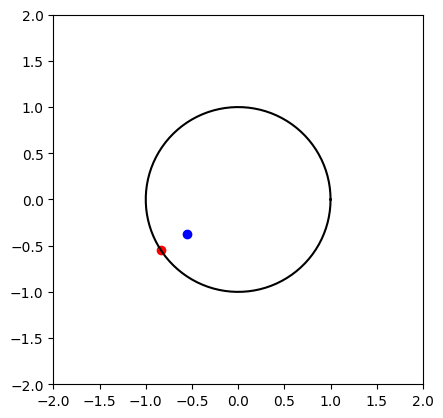

In [9]:
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.gca().set_aspect('equal')
plt.plot(np.cos(np.linspace(0,np.pi*2,100)), np.sin(np.linspace(0,np.pi*2,100)),color="black")
plt.scatter(V_out.value[0,0,0,0].real, V_out.value[0,0,0,0].imag,color="red")
plt.scatter(V_in.value[0,0,0,0].real, V_in.value[0,0,0,0].imag,color="blue")
plt.show()


## Using functionals and optimizers

For realistic problems, we may wish to use existing optimizers in GPT such as Adam.
Here is how.

In [10]:
V_in = rad.node(g.complex(grid))
V_out = rad.node(g.u1(grid))

c = g.norm2(V_in - g.astype(V_out, V_in.otype))

cf = c.functional(V_in, V_out)

v_in = rng.cnormal(g.complex(grid))
v_out = rng.element(g.u1(grid))

# print value of functional for values of fields v_in and v_out
print(cf([v_in, v_out]))

789.6450125039


GPT :       0.565963 s : adam: iteration 0: f(x) = 6.857093962869221e+02, |df|/sqrt(dof) = 1.435254e+00, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       0.646614 s : adam: iteration 40: f(x) = 1.338429956015996e+02, |df|/sqrt(dof) = 8.332229e-02, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       0.731547 s : adam: iteration 80: f(x) = 1.298916802792411e+02, |df|/sqrt(dof) = 1.876294e-02, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       0.817295 s : adam: iteration 120: f(x) = 1.296135697663980e+02, |df|/sqrt(dof) = 6.964285e-03, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       0.903749 s : adam: iteration 160: f(x) = 1.295648778189072e+02, |df|/sqrt(dof) = 3.174206e-03, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       0.990007 s : adam: iteration 200: f(x) = 1.295549087364452e+02, |df|/sqrt(dof) = 1.418829e-03, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       1.028540 s : adam: converged in 219 iterations: f(

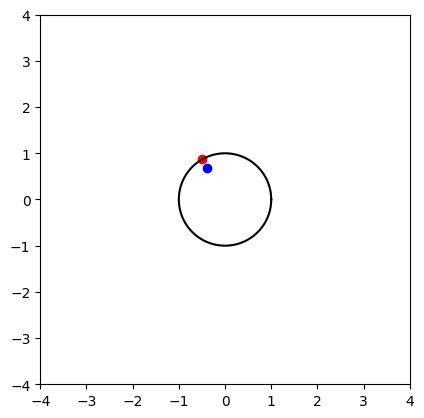

In [11]:
# print(cf.gradient([v_in, v_out], [v_out])

# this is Adam, for now tuned to mimick a simple gradient descent
opt = g.algorithms.optimize.adam(
    maxiter=400, eps=1e-3, eps_regulator=1e8, alpha=0.1*1e8, beta1=0, beta2=1 - 1e-8, 
    log_functional_every=40
)

# now create the optimizer for the functional cf
# and run it by only allowing changes to v_out
opt(cf)([v_in, v_out], [v_out])

# and plot result
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.gca().set_aspect('equal')
plt.plot(np.cos(np.linspace(0,np.pi*2,100)), np.sin(np.linspace(0,np.pi*2,100)),color="black")
plt.scatter(v_out[0,0,0,0].real, v_out[0,0,0,0].imag,color="red")
plt.scatter(v_in[0,0,0,0].real, v_in[0,0,0,0].imag,color="blue")
plt.show()

### Let's learn a Wilson Dirac operator



In [12]:
U = g.qcd.gauge.random(grid, rng)

paths = (
    [g.path()] +
    [g.path().f(mu) for mu in range(4)] +
    [g.path().b(mu) for mu in range(4)]
)

dir_disps = [p.path[0] if len(p.path) > 0 else None for p in paths]

pt = g.parallel_transport(U, paths)

pt_U = pt(U)

# test output of parallel transport
print(g.norm2(pt_U[1] - U[0]))
print(g.norm2(pt_U[4] - U[3]))
print(g.norm2(pt_U[5] - g.cshift(g.adj(U[0]),0,-1)))

node_U = [rad.node(u, with_gradient=False) for u in pt_U]

0.0
0.0
0.0


In [13]:
def layer_pt(inputs):
    assert len(inputs) == len(paths)
    return [
        node_U[i] * g.cshift(inputs[i], *dir_disps[i]) if dir_disps[i] is not None else inputs[i]
        for i in range(len(paths))
    ]

def layer_reduce(weights, inputs):
    assert len(weights) == len(inputs)
    ret = weights[0] * inputs[0]
    for i in range(1, len(inputs)):
        ret += weights[i] * inputs[i]
    return ret

In [14]:
w = g.qcd.fermion.wilson_clover(
    U, mass=0.2, csw_r=0, csw_t=0, xi_0=1, nu=1,
    isAnisotropic=False, boundary_phases=[1,1,1,1]
)

spin_matrices = [
    rad.node(g.mspin(np.zeros((4,4),np.complex128)))
    for i in range(len(paths))
]

V_in = rad.node(g.vspincolor(grid))
V_out = rad.node(g.vspincolor(grid))
layer0 = layer_pt([V_in]*len(paths))
layer1 = layer_reduce(spin_matrices, layer0)

# create training data
rng.cnormal(V_in.value)
V_out.value @= w(V_in.value)

# and cost function
cf = g.norm2(layer1 - V_out).functional(*spin_matrices)

In [15]:
values = [m.value for m in spin_matrices]
cf(values)

127137.96589414496

In [16]:
opt = g.algorithms.optimize.adam(
    maxiter=400, eps=1e-8, eps_regulator=1e8, alpha=0.0001*1e8, beta1=0, beta2=1 - 1e-8, 
    log_functional_every=40
)

opt(cf)(values, values)

GPT :       1.130973 s : adam: iteration 0: f(x) = 6.131711851638347e+04, |df|/sqrt(dof) = 1.651715e+03, alpha = 10000.0, beta1 = 0, beta2 = 0.99999999
GPT :       1.498405 s : adam: iteration 40: f(x) = 1.239488335601369e-04, |df|/sqrt(dof) = 5.217852e-02, alpha = 10000.0, beta1 = 0, beta2 = 0.99999999
GPT :       1.866085 s : adam: iteration 80: f(x) = 2.724753205569706e-12, |df|/sqrt(dof) = 7.555222e-06, alpha = 10000.0, beta1 = 0, beta2 = 0.99999999
GPT :       2.149188 s : adam: converged in 112 iterations: f(x) = 4.185574841793585e-18, |df|/sqrt(dof) = 9.294833e-09


True

In [17]:
print(cf(values))

4.185574841793585e-18


Now we verify the found spin matrices

In [18]:
print(np.linalg.norm(spin_matrices[0].value.array - np.eye(4)*4.2))

2.058546640338888e-11


In [19]:
print(g.norm2(spin_matrices[1].value - 0.5*(g.gamma[0].tensor() - g.gamma["I"].tensor())))
print(g.norm2(spin_matrices[1+4].value - 0.5*(-g.gamma[0].tensor() - g.gamma["I"].tensor())))


9.516647860533578e-22
5.861301612985494e-22


## Defining new operators

We can define new operators as follows

In [20]:
def subtract(x, y):
    def _forward():
        return g(x.value - y.value)

    def _backward(z):
        if x.with_gradient:
            x.gradient += z.gradient
        if y.with_gradient:
            y.gradient -= z.gradient

    z_container = g.ad.reverse.util.get_container(_forward())
    return g.ad.reverse.node_base(_forward, _backward, (x, y), _container=z_container, _tag="subtract")


V_in = rad.node(g.mcolor(grid))
V_out = rad.node(g.mcolor(grid))

rng.element(V_in.value)
rng.element(V_out.value)

# and cost function
cf = g.norm2(subtract(V_in, V_out)).functional(V_in, V_out)

# test functional for self-consistent derivatives
cf.assert_gradient_error(rng, [V_in.value, V_out.value], [V_in.value, V_out.value], 1e-3, 1e-8)

# Homework: modify the _backward above to be incorrect and run the assert_gradient_error again

GPT :       2.166775 s : Test that functional is real: 0.0
GPT :       2.176041 s : Assert gradient error: 2.3516301657649387e-12 < 1e-08


#### More experiments

Next, we consider the performance of the model that just learned the Wilson Dirac operator.
We utilize the framework introduced for the multi right-hand-side coarse operator.

In [21]:
#x0,x1,x2,x3
#xp0=x0 + f0(x1,x3)
#xp2=x2 + f2(x1,x3)

In [22]:
mA = rng.cnormal(g.vspincolor(grid))
mB = rng.element(g.mcolor(grid))
mS = rng.cnormal(g.mspin(grid))

mC = g.vspincolor(grid)
pC = g.pack(mC)
bA = g.pack(mA).to_accelerator_buffer().split_axis(-1, 3, 1)
bB = g.pack(mB).to_accelerator_buffer()
bC = pC.to_accelerator_buffer().split_axis(-1, 3, 1)
print(bA)

accelerator_buffer(49152, (4, 4, 4, 4, 1, 4, 3, 1), complex128)


In [23]:
idxA = bA.indices(range(6))
idxS = bA.indices(range(5))

bS = g.accelerator_buffer(shape=(4,4), dtype=np.complex128)
bS.from_array(mS[0,0,0,0].array)

In [24]:

bD = bC.empty_clone()
b = g.blas()
b.gemm(1.0, bB[idxA // 4], bA[idxA], 0.0, bC[idxA])
b.gemm(1.0, bS[idxS*0], bC.merged_axes(-2, -1)[idxS], 0.0, bD.merged_axes(-2, -1)[idxS])
b()

pC.from_accelerator_buffer(bC)
print(g.norm2(mC - mB * mA))

pC.from_accelerator_buffer(bD)

print(g.norm2(mC - mS[0,0,0,0] * mB * mA))

print(g.norm2(g(mB * mA)[0,0,0,0] - mB[0,0,0,0]*mA[0,0,0,0]))
print(g.norm2(g(mS * mA)[0,0,0,0] - mS[0,0,0,0]*mA[0,0,0,0]))

3.528956217349354e-29
1.2695881378901293e-27
2.644301813643675e-31
1.9844782146966078e-30


In [25]:
# \delta U = dU U^{-1}   ->  V(x) \delta U V(x)^\dagger

In [26]:
#f_lap = g.qcd.gauge.algebra_laplace(U, mass=1/2)

In [37]:
grid = g.grid([16,4,4,4],g.double)
U = [g.mcolor(grid) for _ in range(4)]
#g.qcd.gauge.unit(U)
g.qcd.gauge.random(U, rng)
p_mom = g.group.cartesian(U)
rng.element(p_mom)

even, odd = g.even_odd_projectors(U[0].grid)

g.default.push_verbose("block_cg", True)
aP = g.qcd.scalar.action.hermitian_kernel.mass_term(
    g.qcd.scalar.action.hermitian_kernel.complement(
        U, 
        g.qcd.gauge.algebra_laplace_polynomial(U, 1000, [1/2 + 1/16]*9), 
        [odd]*4, 
        [even]*4
    ),
    g.algorithms.inverter.block_cg({"eps": 1e-15, "maxiter": 300})
)

aP.assert_gradient_error(rng, U + p_mom, U + p_mom, 1e-3, 1e-8)

v0 = aP.draw(U + p_mom, rng)
v1 = aP(U + p_mom)
print(v0, v1)

for x in p_mom:
    x[:] = 0
    x[1,0,0,0,0,0] = 1
res1 = g(aP.inv_M * (U + p_mom))

for x in p_mom:
    x[:] = 0
    x[0,0,0,0,0,0] = 1
res0 = g(aP.inv_M * (U + p_mom))

GPT :     220.667504 s : Test that functional is real: 0.0
GPT :     220.952811 s : Assert gradient error: 6.013488386991923e-10 < 1e-08
GPT :     221.631572 s : block_cg: converged in 47 iterations
16249.602718705491 16249.602718705486


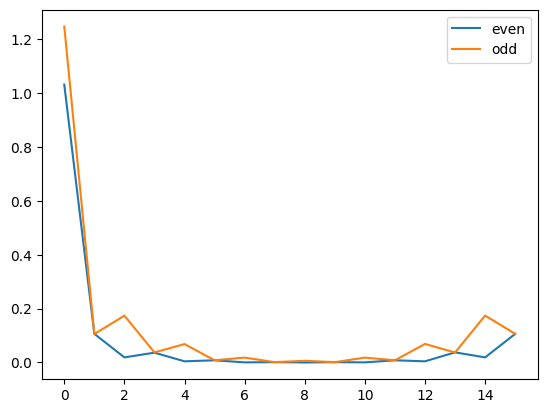

In [38]:
plt.plot(res0[4][:,0,0,0,0,0].real.reshape(16,),label="even")
plt.plot(np.roll(res1[4][:,0,0,0,0,0].real.reshape(16,),-1),label="odd")
plt.legend()
plt.show()